# Data center chiller plant optimization via Mixed-Integer Differentiable Predictive Control

*An instructive, end-to-end implementation accompanying the paper [**Data center chiller plant optimization via mixed-integer nonlinear differentiable predictive control**](https://www.sciencedirect.com/science/article/pii/S0967066126003072).*

Cooling is one of the most energy-intensive aspects of operating a data center, and **chiller plants** are the workers that facilitate it. Controlling such a plant is challenging: it couples **continuous** decisions (chilled-water mass flow, evaporator temperature) with **discrete** decisions (chillers status ON/OFF) through **bilinear** thermal dynamics and **nonlinear** power/performance system characteristics. Formally, this is a *mixed-integer nonlinear optimal control problem*, which is notoriously expensive to solve in real time.

This notebook walks through a compact implementation of **Mixed-Integer Differentiable Predictive Control (MI-DPC)** — a self-supervised, model-based learning method that trains an *explicit neural control policy* offline to approximately solve the MI-OCP, enabling near-instant inference at deployment. It builds on two ideas:

- [**Differentiable Predictive Control (DPC)**](https://www.sciencedirect.com/science/article/pii/S0959152422000981) — casting parametric model predictive control as a differentiable program that can be approximately solved by gradient descent, and
- [**Mixed-Integer DPC (MI-DPC)**](https://arxiv.org/abs/2506.19646) — extending DPC to discrete decisions via *differentiable rounding* with straight-through gradients estimation.

**Contents**

We will
1. build a differentiable **multi-chiller plant model** (thermal dynamics + power/COP model),
2. define **neural control policies** and a **differentiable rounding** layer for the ON/OFF decisions,
3. assemble the **closed-loop computational graph** in [NeuroMANCER](https://github.com/pnnl/neuromancer),
4. **train** the policy using synthetic load scenarios, and
5. **evaluate** it in a receding-horizon closed-loop simulation.

> **Note.** A few parameter values below differ slightly from those reported in the paper. The goal here is a readable, runnable illustration of the *method*, not an exact reproduction of the published benchmark numbers.

## 1. Setup

### Dependencies

The implementation relies on the [**NeuroMANCER**](https://github.com/pnnl/neuromancer) scientific machine-learning library (built on PyTorch). NeuroMANCER provides everything we need to express the optimal control problem as a differentiable program: symbolic `variable`s and `Node`s for the computational graph, MLP `blocks` for the neural control policies, differentiable ODE `integrators` for integrating the plant dynamics, and `PenaltyLoss` for relaxation of process constraints using the penalty method.

Run the cell below if you are on **Google Colab**; skip it when running locally.

In [1]:
!pip install neuromancer

### Imports

Import the NeuroMANCER building blocks.

In [2]:
import torch
from neuromancer.system import Node, SystemPreview
from neuromancer.modules import blocks
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.problem import Problem
from neuromancer.trainer import Trainer
import matplotlib.pyplot as plt
import numpy as np
from neuromancer.dynamics import integrators
from neuromancer.modules.functions import bounds_scaling, bounds_clamp
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device=device) # Set the default device to gpu if available
torch.set_float32_matmul_precision('high')
torch.manual_seed(1312)

/home/desktop309/miniconda3/envs/neuromancer/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/desktop309/miniconda3/envs/neuromancer/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This m

## 2. Problem formulation

We consider a simplified multi-chiller plant whose multiple number of chillers $M$ operate **in parallel** on a shared return-water loop. Each chiller draws warm return water, removes heat across its evaporator, and returns chilled supply water; a binary variable decides whether a chiller is staged ON=1 or OFF=0.

### 2.1 System model — thermal dynamics

The continuous-time thermal dynamics of the multi-chiller system are
\begin{align*}
Q^{(i)}(t) &= \eta_\mathrm{r}\dot{m}^{(i)}(t)\; c_\mathrm{p}\delta^{(i)}(t) \left( T_\mathrm{r}(t)-T^{(i)}_\mathrm{s}(t) \right), \\ 
\dot{T}_\mathrm{r}(t) &= \frac{1}{C_\mathrm{r}}\left(\tilde{Q}_\text{load}(t) - \sum_{i=1}^{M}Q^{(i)}(t) \right), \\
\dot{T}_\mathrm{s}^{(i)}(t) &= -\frac{c_\mathrm{p} \eta_\mathrm{s}}{C^{(i)}}\left(\delta^{(i)}(t)\dot{m}^{(i)}(t) \left(T^{(i)}_\mathrm{s}(t)-T^{(i)}_\mathrm{e}(t)\right)\right),\!\!
\end{align*}
where $Q^{(i)}(t)\!\in\!\mathbb{R}_{\ge0}$ is the delivered cooling from chiller $i$ at time $t$, $\delta^{(i)}(t)\!\in\!\{0,1\}$ denotes the chiller's on/off state, $c_\mathrm{p}\! \in\!\mathbb{R}_{>0}$ is the specific heat capacity of the coolant, and $C_\mathrm{r},C^{(i)}\!\in\!\mathbb{R}_{>0}$ are the thermal capacitances of the return and chiller loops. Moreover, $\eta_\mathrm{r},\eta_\mathrm{s}\!\in\!(0,1)$ denote the heat-exchanger efficiency coefficients, and $\tilde{Q}_\text{load}(t)\!\in\! \mathbb{R}_{\ge0}$ is the effective thermal load. A superscript is used to denote the association between a variable and chiller loop $i\in\{1,\dots,M\}$, i.e., $\dot{m}^{(1)}$ represents the mass flow through the first chiller. Further, quantities sharing the same units are denoted by a common symbol with a subscript, such as $T_\mathrm{e},T_\mathrm{s},T_\mathrm{r}$ for the evaporator, supply, and return temperatures, respectively.

<div style="background-color: white; width: 600px; margin: 0 auto; padding: 20px; text-align: center;">
  <img src="aux/images/chiller_diagram.png" alt="Alt text" width="500">
</div>

In this model, the effective thermal load $\tilde{Q}_\text{load}(t)\in\mathbb{R}_{\ge0}$ is estimated using a low-pass, discrete-time finite impulse response (FIR) filter
\begin{equation*}
\tilde{Q}_\text{load}(t) = \sum_{l=0}^{L} h_l\, Q_\text{load}(t - l\,\Delta t),
\end{equation*}
where $Q_\text{load}\in\mathbb{R}_{\ge0}$ is the direct server load—an exogenous variable in this context, $\Delta t$ denotes the length of a discrete-time step, $L\in\mathbb{N}_{\ge1}$ is the filter order, and $(h_l)_{l=0}^{L}\in\mathbb{R}_{>0}$ are the filter coefficients, with $\sum_l h_l = 1$. The FIR filter is used to capture higher-order heat-transfer dynamics, enhancing the model's expressive capacity, where the filter coefficients can be estimated along with other parameters using traditional system identification methods.

Note that $Q_\text{load}$ is treated as a deterministic known variable in this study.

### 2.2 Power consumption and the COP–PLR trade-off

The chillers are by far the most energy-intensive components, so the control objective is ultimately about minimizing electrical power. The power consumption of chillers $P^{(i)}_\text{chiller}(t)\in\mathbb{R}_{\ge 0}$ and pumps $P^{(i)}_\text{pump}(t)\in\mathbb{R}_{\ge 0}$ are modeled as
\begin{align*}
P^{(i)}_\text{chiller}(t) &= \frac{Q^{(i)}(t)}{\text{COP}^{(i)}(t)}+\rho^{(i)}\delta^{(i)}(t) ,\\
\text{COP}^{(i)}(t) &= a_0^{(i)}+a_1^{(i)}\frac{Q^{(i)}(t)}{Q_\text{max}^{(i)}}+a_2^{(i)}\left(\frac{Q^{(i)}(t)}{Q_\text{max}^{(i)}}\right)^2,\\
P^{(i)}_\text{pump}(t) &= \gamma^{(i)}\left( \dot{m}^{(i)}(t)\delta^{(i)}(t) \right)^3, 
\end{align*}
for the system constants $a_{0:2}^{(i)},\gamma^{(i)},\rho^{(i)},Q_\text{max}^{(i)}\!\in\!\mathbb{R}$. The constant $\rho$ represents the base power required for chiller operation. In this formulation, the chiller's coefficient of performance $\text{COP}^{(i)}(t)\in\mathbb{R}_{\ge0}$ is a quadratic function of the **part-load ratio (PLR)** — the ratio of current cooling to maximum cooling capacity. This is the crux of the optimization: a chiller is most efficient near a specific load ratio, so keeping each *active* unit close to its sweet spot (by staging the right number of chillers and tuning their continuous setpoints) is what yields energy savings.




> **Optional ramp-rate limits.** Real chillers cannot change their cooling output arbitrarily fast [(reported in)](https://www.sciencedirect.com/science/article/pii/S0306261921007662). The given model therefore supports an *optional* ramp constraint on the delivered cooling: when `system.ramp_limits = True`, the per-chiller cooling is not allowed to move by more than `ramp_rate_ub` (up) or `ramp_rate_lb` (down) as a fraction of $Q_\text{rated}$ between consecutive steps. It is enforced in a differentiable way by a dedicated *cooling node* that feeds the (clamped) `Q_delivered` into the dynamics, so it shapes both training and the closed-loop rollout.

The following code defines a multi-chiller plant class, where the system constants and process constraints are defined.

In [3]:
class ChillerSystem(torch.nn.Module):
    def __init__(self):
        super(ChillerSystem, self).__init__()
        self.M = 3 # Number of chillers
        self.Ts = 100 # Sampling time [s]
        self.c_p = 4.184 # Specific heat capacity of the coolant
        self.fluid_per_chiller = 3500 # kg of water per chiller / ~liters
        self.C_i = self.c_p * self.fluid_per_chiller # Thermal capacitance of chiller [kJ/C] 
        self.fluid_in_system = 7000 # Amount of fluid in the whole system [kg] / ~[liter]
        self.C_r = self.fluid_in_system*self.c_p # Thermal capacitance of the system [kJ/C]
        self.inv_C_i = 1.0 / self.C_i # Inverse of the chiller loop capacitance
        self.inv_C_r = 1.0 / self.C_r # Inverse of the return loop capacitance

        self.eta_return = 0.75 # Heat exchanger efficiency
        self.eta_supply = 0.7 # Heat exchanger efficiency
        

        self.a = 1. # Chiller COP model coefficients
        self.b = 19.33
        self.c = -18.33
        self.chiller_on_cost = 10 # Cost of chiller on [kW]
        self.gamma = 0.0001 # Pump power model coefficients
        self.exponent = 3 # Pump power model exponent
        

        self.Q_rated = 500 # Maximum rated cooling per chiller [kW]
        
        self.T_supply_min = 7 # Temperature bounds [C]
        self.T_supply_max = 12
        self.T_return_min = 7
        self.T_return_max = 30
        self.T_evap_min = 7
        self.T_evap_max = 12
        self.flow_min = 7 # Minimum mass flow rate [kg/s]
        self.flow_max = 30 # Maximum mass flow rate [kg/s]
        
        self.load_min = 0 # Minimum expected load [kW]
        self.load_max = 0.75*(self.Q_rated*self.M) # Maximum expected load [kW]
        
        
        self.load_filter = [.6, .4] # FIR filter coefficients
        self.register_buffer("h_filter", torch.tensor(self.load_filter, dtype=torch.float32))
        self.L = len(self.load_filter) # Filter length
        self.register_buffer("load_buffer", torch.zeros((1, self.L)))  # shape (1, L), expanded later per batch

        self.in_features = 1
        self.out_features = self.M + 1
       
        # --- cooling ramp-rate limits -----------------------------------
        # When `ramp_limits` is True, the delivered cooling per chiller is not allowed
        # to change by more than a fraction of the rated capacity from one discrete time step to the
        # next. The bounds are expressed as a fraction of `Q_rated` per sampling step.
        self.ramp_limits = True    # toggle the feature ON/OFF (set True to enable)
        self.ramp_rate_ub = 0.02    # max fractional increase of cooling per discrete step (0.02 = 2% of rated cooling)
        self.ramp_rate_lb = 0.02    # max fractional decrease of cooling per discrete step (0.02 = 2% of rated cooling)
        # `previous_cooling` stores last step's delivered cooling so the ramp can be
        # enforced in the closed loop; it is reset when the batch shape
        # changes (e.g. between training and evaluation).
        self.register_buffer("previous_cooling", torch.zeros((1, self.M)), persistent=False)

Next, we define a `forward` method for computing continuous-time system dynamics.

In [4]:
# Continuous-time dynamics
def forward(self, T_supply_and_return, integer_status, mass_flow, T_evap, load, cooling_delivered=None) -> torch.Tensor:    
    T_supply = T_supply_and_return[...,:self.M]
    T_return = T_supply_and_return[...,self.M:]

    delta_supply_evap = T_supply - T_evap
    delta_return_supply = T_return - T_supply

    dT_supply_next = self.inv_C_i * (-self.c_p * integer_status * mass_flow * delta_supply_evap) * self.eta_supply

    # When ramp limiting is enabled we use the ramp-limited cooling supplied by the
    # cooling node (held constant across the integrator [e.g. RK4] sub-steps). Otherwise we keep
    # the original behaviour and recompute the cooling.
    if (cooling_delivered is None) or (not self.ramp_limits):
        cooling_delivered = torch.clip(
            self.c_p * integer_status * mass_flow * delta_return_supply * self.eta_return,
            min=0., max=self.Q_rated*1.01)
    energy_diff = torch.sum(cooling_delivered, dim=-1, keepdim=True)
    dT_return_next = self.inv_C_r * (load - energy_diff)

    return torch.cat([dT_supply_next, dT_return_next], dim=-1)
ChillerSystem.forward = forward

The methods below compute the **delivered cooling**, the **chiller power consumption** (via the COP–PLR curve), and the **pump power** per chiller.

In [5]:
def get_pump_consumption(self, integer_status, mass_flow) -> torch.Tensor: # Compute pump power consumption
    power = self.gamma * torch.pow(mass_flow, self.exponent)
    total_power = integer_status * (power)
    return total_power
ChillerSystem.get_pump_consumption = get_pump_consumption


def get_chiller_power_PLR_(self,*, cooling, integer_status) -> torch.Tensor: # Compute chiller power consumption using the COP-PLR curve
    # COP-PLR power model evaluated using the pre-computed delivered cooling
    # (e.g. the ramp-limited `Q_delivered` recorded during the closed-loop rollout).
    PLR = torch.clip(cooling / self.Q_rated, min=0., max=1.05) 
    COP = self.a+self.b*PLR+self.c*torch.square(PLR) 
    COP = torch.clip(COP, min=0., max=torch.inf)
    power = cooling / (COP)
    power = torch.clip(power, min=0., max=self.Q_rated*1.01) # gives stable training
    return power + integer_status*self.chiller_on_cost
ChillerSystem.get_chiller_power_PLR_ = get_chiller_power_PLR_


def get_cooling_delivered_per_chiller(self, integer_status, mass_flow, T_return, T_supply, ramp_bounds=None, update_memory=True) -> torch.Tensor: # Compute delivered cooling per chiller
    cooling_power = integer_status*self.c_p*mass_flow*(T_return - T_supply)
    cooling_power = torch.clip(cooling_power*self.eta_return, min=0., max=self.Q_rated*1.01)

    # # #  Optional ramp-rate limiting: clamp the change in delivered cooling relative to the previous step.
   
    ramp_bounds = self.ramp_limits if ramp_bounds is None else ramp_bounds # Defaults to the system. `ramp_limits` toggle when not specified.
    if not ramp_bounds:
        return cooling_power # <--- This is the case when self.ramp_limits is False

    nch = cooling_power.shape[-1] # Infer number of chillers
    device = cooling_power.device # Infer device
    B = cooling_power.numel() // nch # Infer batch size
    cp_2d = cooling_power.reshape(B, nch) # Reshape to 2D

    up = self.ramp_rate_ub * self.Q_rated   # max increase per step [kW]
    dn = self.ramp_rate_lb * self.Q_rated   # max decrease per step [kW]

    # (Re)initialize the memory when it is missing or the batch shape changed; the first
    # step of a rollout is therefore unconstrained.
    if (self.previous_cooling is None or
        self.previous_cooling.shape != (B, nch) or
        self.previous_cooling.device != device):
        self.previous_cooling = cp_2d.detach().to(device)

    max_up = self.previous_cooling + up # Compute max increased cooling
    max_dn = self.previous_cooling - dn # Compute max decreased cooling
    cp_2d = torch.max(torch.min(cp_2d, max_up), max_dn) # Clamp the cooling

    if update_memory:
        self.previous_cooling = cp_2d.detach()

    return cp_2d.view_as(cooling_power)
ChillerSystem.get_cooling_delivered_per_chiller = get_cooling_delivered_per_chiller

def get_cooling_for_node(self, integer_status, mass_flow, T_supply_and_return) -> torch.Tensor:
    # Node-friendly wrapper: split the combined [T_supply ; T_return] state and compute the
    # (optionally ramp-limited) delivered cooling, updating the ramp memory once per step.
    T_supply = T_supply_and_return[..., :self.M]
    T_return = T_supply_and_return[..., self.M:]
    return self.get_cooling_delivered_per_chiller(integer_status, mass_flow, T_return, T_supply,
                                                  update_memory=True)
ChillerSystem.get_cooling_for_node = get_cooling_for_node

def apply_load_filter(self, load: torch.Tensor) -> torch.Tensor: # FIR filter for load
        batch_size = load.shape[0]
        device = load.device

        # Accept multiple load shapes and always extract the current scalar load per sample.
        if load.ndim == 1:
            load_flat = load
        elif load.ndim == 2:
            load_flat = load[:, 0]
        elif load.ndim == 3:
            load_flat = load[:, 0, 0]
        else:
            raise ValueError(f"Unsupported load shape: {tuple(load.shape)}")

        # Allocate once if needed
        if (not hasattr(self, 'load_buffer') or
            self.load_buffer.shape[0] != batch_size or
            self.load_buffer.device != device):
            self.load_buffer = load_flat.unsqueeze(1).repeat(1, self.L).to(device)
            filtered_flat = load_flat.unsqueeze(1)
            return filtered_flat

        # Ensure h_filter on same device
        if self.h_filter.device != device:
            self.h_filter = self.h_filter.to(device)

        # ---- SAFE IN-PLACE UPDATE ----
        self.load_buffer[:, 1:] = self.load_buffer[:, :-1].clone()
        self.load_buffer[:, 0] = load_flat

        # Compute filtered output
        filtered_flat = torch.sum(self.load_buffer * self.h_filter, dim=1, keepdim=True)
        return filtered_flat
ChillerSystem.apply_load_filter = apply_load_filter


system = ChillerSystem() # Initialize the system

## 3. The MI-DPC controller

We now turn the optimal control problem into a **differentiable program** that can be trained end-to-end. The closed-loop graph has four ingredients: continuous neural policies, a differentiable rounding (quantization) layer for the binary decisions, a differentiable ODE solver for the plant dynamics, and a model-predictive loss evaluated over rollout trajectories. We build them up one piece at a time.

### 3.1 Differentiable rounding for on/off decisions

The on/off staging decisions are binary, $\delta^{(i)}_k\in\{0,1\}$, which makes the problem non-differentiable. We obtain $\delta$ by **thresholding** a relaxed value $\tilde\delta$ at $0.5$, and recover approximate gradients with a **straight-through estimator**: the forward pass uses the hard threshold, while the backward pass utilizes the gradient of a smooth scaled-sigmoid surrogate. The thresholding rule is

\begin{align*}
\delta^{(i)}_{k} = & \begin{cases}
    1, & \text{if } \tilde\delta^{(i)}_{k}>0.5,\\[0pt]
0, & \text{otherwise,}\\[0pt]
\end{cases}
    \end{align*}
 where $\tilde\delta$ denotes the relaxed value of the binary variable $\delta$. Furthermore, the sigmoid function is defiend as $\sigma(x)\!=\!{\left(1+e^{-\mu (x-0.5)} \right)}^{-1},$ where $\mu\in\mathbb{R}_{>0}$ denotes the slope coefficient and $0.5$ is the rounding threshold. Subsequently, the gradients are computed as 

 \begin{align*}
    \frac{\partial \delta^{(i)}_{k}}{\partial \tilde{\delta}^{(i)}_{k}} 
    := \frac{\partial \sigma\!\left(\tilde{\delta}^{(i)}_{k}\right)}{\partial \tilde{\delta}^{(i)}_{k}}.
\end{align*}

In [6]:
def relaxed_binary(x, slope=1.0, threshold=0.5):
        logits = slope * (x - threshold)
        sig = torch.sigmoid(logits)
        return (x > threshold).float() + (sig - sig.detach())
        #  forward pass↑      backward pass↑    no grad↑ 

### 3.2 Neural control policies

The explicit control law is split into **three independent neural modules** $\pi_{\theta_1},\pi_{\theta_2},\pi_{\theta_3}$ — one per decision type (mass flow, evaporator temperature, and the relaxed binary staging). Each is a simple feed-forward network (three hidden layers of width $200$ with nonlinear activations). They all share the same input: the current state stacked with a length-$N$ **preview** of the upcoming thermal load, which is what lets the policy act proactively. We also fix the prediction horizon length $N$ here as `nsteps`.

In [7]:
nsteps = 60 # prediction horizon length
mlp_delta = blocks.MLP(insize=1*system.M+1+1*(nsteps)+1, outsize=system.M-1, bias=True, # relaxed binary policy
                    linear_map=torch.nn.Linear,
                    nonlin=torch.nn.GELU,
                    hsizes=[200, 200, 200])
mlp_flow_rate = blocks.MLP(insize=1*system.M+1+1*(nsteps)+1, outsize=system.M, bias=True, # mass flow policy
                    linear_map=torch.nn.Linear,
                    nonlin=torch.nn.ReLU,
                    hsizes=[200, 200, 200])
mlp_T_evap = blocks.MLP(insize=1*system.M+1+1*(nsteps)+1, outsize=system.M, bias=True, # evaporator temperature policy
                    linear_map=torch.nn.Linear,
                    nonlin=torch.nn.ReLU,
                    hsizes=[200, 200, 200])

if device == 'cuda':
    mlp_delta = torch.compile(mlp_delta)
    mlp_flow_rate = torch.compile(mlp_flow_rate)
    mlp_T_evap = torch.compile(mlp_T_evap)

Neural networks train more reliably when their inputs live on a common scale, so we $[0,1]$-**normalize** every policy input variable. The vectors below hold the physical lower and upper bounds of each input — the $M$ supply temperatures, the return temperature, and the load preview values — used for that normalization.

In [8]:
mins = [system.T_supply_min] * system.M + [system.T_return_min] * 1 + [system.load_min] * (nsteps+1) 
maxs = [system.T_supply_max] * system.M + [system.T_return_max] * 1 + [system.load_max] * (nsteps+1) 

The wrapper below couples each MLP with **input normalization**. Inputs are mapped to $[0,1]$. During inference, continuous outputs can optionally be **clipped** again onto their feasible sets, guaranteeing that mass flows and evaporator temperatures never violate their physical actuator limits.

In [9]:
class PolicyWithInputNorm(torch.nn.Module):
    def __init__(self, mlp, mins=None, maxs=None, u_min=None, u_max=None, clipping=False, sigmoid_clipping=False):
        super().__init__()
        if mins is None or maxs is None:
            raise ValueError("You must provide mins and maxs for each input variable.")
        self.mlp = mlp
        self.register_buffer("mins", torch.tensor(mins, dtype=torch.float32))
        self.register_buffer("maxs", torch.tensor(maxs, dtype=torch.float32))
        self.register_buffer("u_min", torch.tensor(u_min, dtype=torch.float32))
        self.register_buffer("u_max", torch.tensor(u_max, dtype=torch.float32))
        self.clipping = clipping
        self.sigmoid_clipping = sigmoid_clipping

    def norm_0_1(self, x):
        denom = self.maxs - self.mins
        denom = torch.where(denom == 0, torch.ones_like(denom), denom)  # avoid division by zero
        return (x - self.mins) / denom

    def forward(self, *inputs):
        if len(inputs) > 1:
            x = torch.cat(inputs, dim=-1)
        else:
            x = inputs[0]
        x = self.norm_0_1(x)
        out = self.mlp(x)
        if self.clipping:
            if self.sigmoid_clipping:
                out = bounds_scaling(out, self.u_min, self.u_max) # sigmoid-based saturation (for more info see the function source)
            else:
                out = bounds_clamp(out, self.u_min, self.u_max) # linear saturation (for more info see the function source)
        return out

We instantiate the three policies — one per decision variable. Note that, the outputs of the relaxed binary policy are scaled (saturated) to $[-2,2]$ to ensure stable training, while the outputs of policies for continuous-valued decision variables are not saturated.

In [10]:
policy_integer = PolicyWithInputNorm(mlp_delta, mins=mins, maxs=maxs, u_min=-2., u_max=2., clipping=True, sigmoid_clipping=True) # relaxed binary policy
policy_flow = PolicyWithInputNorm(mlp_flow_rate, mins=mins, maxs=maxs, u_min=system.flow_min, u_max=system.flow_max, clipping=False, sigmoid_clipping=False) # mass flow policy
policy_evap = PolicyWithInputNorm(mlp_T_evap, mins=mins, maxs=maxs, u_min=system.T_evap_min, u_max=system.T_evap_max, clipping=False, sigmoid_clipping=False) # evaporator temperature policy

### 3.3 Differentiable system dynamics

The continuous-time thermal ODEs from Section 2.1 are advanced one step with a **forward Euler** integrator, $x_{k+1}=\text{ODESolve}(x_k,u_k, \Delta t)$, where the state is $x_k\!:=\![T_{\mathrm{r},k}^\top,T_{\mathrm{s},k}^{(1)\top},\dots,T_{\mathrm{s},k}^{(M)\top}]^\top$ and the per-chiller decisions are $u^{(i)}_k\!:=\!\{\delta^{(i)}_k,T_{\mathrm{e},k}^{(i)},\dot{m}^{(i)}_k\}$. Here, the gradients flow through the entire dynamics rollout, allowing the policies to be trained directly with respect to the closed-loop response.

In [11]:
integrator = integrators.Euler(system, h=torch.tensor(system.Ts))

### 3.4 Wiring the computational graph

In NeuroMANCER, each component is wrapped in a `Node` class that defines which dictionary keys are declared as (`input_keys`) and (`output_keys`). Chaining nodes by their keys is what defines the data flow. Here we register nodes for the **system dynamics**, the **three policies**, and the **load filter** (the aforementioned low-pass FIR filter).

In [12]:
# Compute the (optionally ramp-limited) delivered cooling once per step and feed it to the
# dynamics so the ramp constraint is reflected in the closed-loop temperatures.
cooling_node = Node(system.get_cooling_for_node,
                        input_keys=['integer', 'flow', 'T_supply_and_return'],
                        output_keys=['Q_delivered'],
                        name='cooling')

# system dynamics integrator
dynamics_node = Node(integrator,
                        input_keys=['T_supply_and_return', 'integer', 'flow', 'T_evap', 'filtered_load', 'Q_delivered'],
                        output_keys=['T_supply_and_return'],
                        name='system_dynamics')

# relaxed binary policy
policy_integer_node = Node(policy_integer,
                input_keys=['T_supply_and_return','load', 'filtered_load'],
                output_keys=['relaxed_integer'],
                name='policy_integer')

# mass flow policy
policy_flow_node = Node(policy_flow,
                input_keys=['T_supply_and_return','load', 'filtered_load'],
                output_keys=['flow'],
                name='policy_flow')

# evaporator temperature policy
policy_evap_node = Node(policy_evap,
                input_keys=['T_supply_and_return','load', 'filtered_load'],
                output_keys=['T_evap'],
                name='policy_evap')

# load filter
load_filter_node = Node(system.apply_load_filter, input_keys=['load'], output_keys=['filtered_load'])




Next we wrap the differentiable rounding in its own `Node`. To conservatively enforce the *"at least one chiller on at all time"* safety constraint $\sum_i \delta^{(i)}_k \ge 1$, we conservatively **fix one chiller to be always on** ($\delta^{(1)}_k = 1$) and let the policy decide the remaining $M{-}1$ binary states. This also reduces the dimension of the relaxed decision $\tilde\delta$ to $M{-}1$.

In [13]:
def round_fn(x):
        return torch.cat((torch.ones((x.size(0), 1), requires_grad=True), relaxed_binary(x)), dim=-1)

rounding_node = Node(round_fn, input_keys=['relaxed_integer'], output_keys=['integer'], name='soft_rounding')

### 3.5 Closed-loop system with load preview

The `SystemPreview` ties all the nodes together into a single closed-loop rollout of length `nsteps`. At every step it feeds the policies not just the current state but also a **preview window** of the upcoming load (`preview_length`), which is exactly the look-ahead that gives predictive control its edge over reactive rule-based staging. Executing this object performs the single-shooting forward pass of the dynamics.

In [14]:
# NEUROMANCER SYSTEM
cl_system = SystemPreview([load_filter_node, policy_integer_node, rounding_node, policy_evap_node, policy_flow_node , cooling_node, dynamics_node],
                                nsteps=nsteps, name='cl_system', pad_mode='reflect',
                                preview_keys_map={'load': ['policy_flow', 'policy_integer', 'policy_evap']}, # parse a preview window of 'load' variable and feed it to 'policy_*' nodes
                                preview_length={'load': nsteps-1})

### 3.6 The optimal control problem

With the forward model in place, we define the loss. NeuroMANCER lets us write the objective and constraints symbolically: a `variable` references a key in the trajectory dictionary, and algebraic expressions over these variables are automatically differentiable. Below we declare the symbolic decision/state/exogenous variables.

In [15]:
relaxed_integer_variable = variable('relaxed_integer') # Decision
integer_variable = variable('integer') # Decisions
flow_variable = variable('flow') # Decision
T_evap_variable = variable('T_evap') # Decision
load_variable = variable('load') # Exogenous
T_supply_and_return_variable = variable('T_supply_and_return') # State
cooling_delivered_variable = variable('Q_delivered')

The reformulated parametric mixed-integer optimal control problem is solved *in expectation* over sampled load scenarios and initial conditions (i.e. control parameters) $\xi\sim P_\xi$. The objective trades off **energy** (chiller + pump power) against **load tracking**, while extra terms tame the discrete behavior: a **switching penalty** $\|\Delta\delta_k\|_R^2$ discourages frequent on/off cycling, and a **binary-variance regularization** $\|\tilde\delta_k\odot(1-\tilde\delta_k)\|_\Lambda^2$ polarizes the relaxed binary decision variable. State and input constraints are folded in as penalty terms $\lambda_x q(x_k)$ and $\lambda_u p(u_k)$.
\begin{align} \nonumber
        \min_{\theta_1,\theta_2,\theta_3}\mathbb{E}_{ \xi \sim P_{ \xi} }\!  
           &\bigg[\sum_{k=0}^{N-1} \sum^M_{i=1} 
           \underbrace{P^{(i)}_{\text{chiller},k}}_{\text{chiller power}}\!+\! 
           \underbrace{P^{(i)}_{\text{pump},k}}_{\text{pump power}}\!+\!
            \underbrace{\|\Delta\delta_k\|_R^2}_{\substack{\text{switching} \\ \text{penalty}}} \!+\! 
            \lambda_W \underbrace{\left(Q_k\!-\!Q_{\text{load},k}\right)^2}_{\text{load tracking}} \!+\!
             \underbrace{\lambda_x q(x_k)}_{\substack{\text{state cosntr.} \\ \text{penalty}}} \!+\!
             \underbrace{\lambda_u p(u_k)}_{\substack{\text{input constr.} \\ \text{penalty}}} \!+\! 
             \underbrace{\|\tilde\delta_k\odot(1-\tilde\delta_k)\|^2_\Lambda}_{\substack{\text{binary-variance} \\ \text{regularization}}}\bigg]\\[-0pt]
        {\text{subject to}} \nonumber\\[-0pt]
        \;  x_{k+1}=&f\left(x_k, u_k,\tilde{Q}_{\text{load},k}, \Delta t\right),  \color{gray}{\leftarrow\text{dynamics}}\\
        \dot{m}_k\!=&\,\pi_{\theta_1}(\xi_k),\;  \color{gray}{\leftarrow\text{mass flow rate decision}}\\
        T_{\mathrm{e},k}\!=&\,\pi_{\theta_2}(\xi_k),\; \color{gray}{\leftarrow\text{evaporation temperature decision}}\\
        \tilde\delta_k\!=&\,\pi_{\theta_3}(\xi_k), \color{gray}{\leftarrow\text{relaxed binary decision}}\\
        \delta_k \in &\;\{0,1\}^M, \;\, \forall k \in \{0,\dots,N\!-\!1\}, \color{gray}{\leftarrow\text{integrality constraint}}\\
        \delta^{(2)}_k =& \,1,\;\quad\quad\quad \forall k\in\{0,\dots,N-1\}, \color{gray}{\leftarrow\text{"one-ON" safety constraint}}\\
        Q_k\!=&\!\sum_i^M Q^{(i)}_k  \quad\, \forall k \in \{0,\dots,N\!-\!1\},\\
        \xi_k\!:=&\!\;[x_k^\top, \tilde{Q}_{\text{load},k}^\top, Q_{\text{load},k}^\top,\dots,Q_{\text{load},k\!+\!N}^\top]^\top\!\!\!. \color{gray}{\leftarrow\text{control parameters vector}}
        \end{align} 

In [16]:
chiller_loss = ((torch.sum(system.get_chiller_power_PLR_(cooling=cooling_delivered_variable,
                                                        integer_status=integer_variable),dim=-1,keepdim=True) == 0.)) # minimize chiller power consumption
        
pump_loss = ((torch.sum(system.get_pump_consumption(mass_flow=flow_variable, 
                                integer_status=integer_variable),dim=-1,keepdim=True) == 0.)) # minimize pump power consumption

cooling_loss = 1e-5*((torch.sum(cooling_delivered_variable,dim=-1,keepdim=True) == load_variable)^2.) # track cooling demand profile
switching_loss = 80.*((integer_variable[:, 1:, :] == integer_variable[:, :-1, :])^2) # minimize binary switching
binary_regularization = 250.*((relaxed_integer_variable * (1-relaxed_integer_variable) == 0.)^2.) # penalize binary variance

chiller_loss.name = 'chiller_loss'; pump_loss.name = 'pump_loss'; binary_regularization.name = 'BVR_loss'
switching_loss.name = 'switching_loss'; cooling_loss.name = 'cooling_loss'
loss_list = [chiller_loss, pump_loss, cooling_loss, switching_loss, binary_regularization]

**Constraints via penalty relaxation.** Rather than enforcing the operating limits as hard constraints, we relax them into soft **penalty terms** that are added to the loss whenever a bound is violated. This keeps the whole problem differentiable. We penalize violations of the return- and supply-temperature bounds, as well as the mass-flow and evaporator-temperature actuator limits.

In [17]:
T_return_lb  = 10.*(T_supply_and_return_variable[:,:,system.M:] >= system.T_return_min) # State constraints
T_return_ub = 300.*(T_supply_and_return_variable[:,:,system.M:] <= system.T_return_max)
T_supply_lb = 10.*(T_supply_and_return_variable[:,:,:system.M] >= system.T_supply_min) 
T_supply_ub = 10.*(T_supply_and_return_variable[:,:,:system.M] <= system.T_supply_max)


input_constraints_const = 100. # input constraints
flow_lb = input_constraints_const*(flow_variable >= system.flow_min); flow_ub = input_constraints_const* (flow_variable <= system.flow_max) 
T_evap_lb = input_constraints_const*(T_evap_variable >= system.T_evap_min); T_evap_ub = input_constraints_const* (T_evap_variable <= system.T_evap_max)

T_return_lb.name, T_return_ub.name = 'T_return_lb','T_return_ub'
T_supply_lb.name, T_supply_ub.name = 'T_supply_lb','T_supply_ub'
flow_lb.name, flow_ub.name = 'flow_lb','flow_ub'
T_evap_lb.name, T_evap_ub.name = 'T_evap_lb', 'T_evap_ub`'

constraints = [
        T_return_lb,
        T_return_ub,
        T_supply_lb, T_supply_ub,
        flow_lb, flow_ub,
        T_evap_lb, T_evap_ub,
        ]


Finally, the objective terms and the constraint penalties are bundled into a single `PenaltyLoss`, and the loss is paired with the closed-loop system in a `Problem` object, which represents the differentiable program.

In [18]:
# PROBLEM DEFINITION
loss = PenaltyLoss(loss_list, constraints)
problem = Problem([cl_system], loss)

## 4. Numerical experiments

### 4.1 Synthetic cooling-load scenarios

DPC is **self-supervised**: there are no labeled optimal trajectories. Instead, we train on a large set of plausible operating scenarios sampled from a distribution $P_\xi$. The generator below synthesizes realistic data-center load profiles with day/night cycles, smooth ramp transitions, randomized oscillations and drift — emulating the variation a plant would actually experience.

In [19]:
def generate_datacenter_load(
sampling_time=system.Ts,   # seconds
number_of_days=1,   #  Number of days 
ramp_hours=4,       # transition duration [h]
night_baseline=250, # kW
osc_night_amp=120,  # nighttime oscillation amplitude [kW]
day_baseline=0.85*system.load_max,   # kW  (kept below the M*Q_max plant capacity)
osc_day_amp=0.1*system.load_max,    # daytime oscillation amplitude [kW]
noise_scale=00,     # base random noise [kW]
ramp_jitter=00,     # extra noise during transitions [kW]
f_day=2,            # frequency day
f_night=4,          # frequency night
daily_variation=0.1, # relative variation per day
signal_seed=303,
):
    def smooth_transition(x, start, end):
        """Smooth 0→1 cosine ramp between start and end hours"""
        phase = torch.clamp((x - start) / (end - start), 0, 1)
        return 0.5 * (1 - torch.cos(torch.pi * phase))

    torch.manual_seed(signal_seed)
    # total samples for N days
    total_seconds = (24 * 3600) * number_of_days
    n_samples = int(total_seconds // sampling_time)
    t = torch.arange(n_samples) * sampling_time / 3600  # time in hours
    load = torch.zeros(n_samples)

    for d in range(number_of_days):
        day_offset = slice(d * n_samples // number_of_days,
                           (d+1) * n_samples // number_of_days)
        td = t[day_offset]  # hours for this day

        # stochastic day baselines & oscillations
        db_var = day_baseline() if callable(day_baseline) else day_baseline
        db = db_var * (1 + daily_variation * torch.rand(1).uniform_(-1,1).item())
        nb_var = night_baseline() if callable(night_baseline) else night_baseline
        nb = nb_var * (1 + daily_variation * torch.rand(1).uniform_(-1,1).item())
        oda = osc_day_amp * (1 + daily_variation * torch.rand(1).uniform_(-1,1).item())
        ona = osc_night_amp * (1 + daily_variation * torch.rand(1).uniform_(-1,1).item())

        # day/night factor
        day_factor = smooth_transition(td % 24, 12 - ramp_hours, 12) \
                   * (1 - smooth_transition(td % 24, 20, 20 + ramp_hours))
        baseline = nb + (db - nb) * day_factor

        # daily sinusoidal drift with random phase
        drift_phase = 2 * torch.pi * torch.rand(1).item()
        trend = 0.05 * baseline * torch.sin(2 * torch.pi * td / 24 + drift_phase)

        # oscillations with randomized frequencies
        freq_day = (f_day + torch.randn(1).item() * 0.5) / 24
        freq_night = (f_night + torch.randn(1).item() * 0.5) / 24
        osc_day   = oda * torch.sin(2 * torch.pi * td * freq_day)
        osc_night = ona * torch.sin(2 * torch.pi * td * freq_night)
        oscillations = day_factor * osc_day + (1 - day_factor) * osc_night

        # base random noise
        noise = torch.randn(len(td)) * noise_scale

        # extra jitter around ramp hours
        ramp_mask = ((td % 24 >= 8 - ramp_hours) & (td % 24 <= 8 + ramp_hours)) | \
                    ((td % 24 >= 20 - ramp_hours) & (td % 24 <= 20 + ramp_hours))
        transition_noise = ramp_mask.float() * torch.randn(len(td)) * ramp_jitter

        # random walk for slow drift
        random_walk = torch.cumsum(torch.randn(len(td)) * 0.05, 0)

        load[day_offset] = baseline + trend + oscillations + noise + transition_noise + random_walk
    load = torch.clamp(load, min=0)
    return t, load

### 4.2 Building the training dataset

Each training sample is a control-parameter vector $\xi$: a randomly initialized plant state together with a length-`nsteps` slice of the synthetic load. Sampling a large, diverse batch of such scenarios is what lets the policy generalize across the operating envelope.

In [20]:
num_data = 40000; num_train_data = num_data//2; batch_size = num_train_data # dataset size
T_supply_t = torch.rand(num_data, 1, system.M).uniform_(system.T_supply_min, system.T_supply_max) # random sampling from a uniform distribution covering the variable's operational range
T_return_t = torch.amax(T_supply_t, dim=-1, keepdim=True)

steps_per_day = int(round(24 * 3600 / system.Ts))
days_needed = int(np.ceil(num_data * nsteps / steps_per_day)) + 1
_, loads_t_1d = generate_datacenter_load(number_of_days=days_needed, sampling_time=system.Ts)

loads_t = loads_t_1d[:num_data*(nsteps)].reshape(num_data,nsteps,1) # shape [batch, nsteps, number of features]

We split the scenarios into **training** and **development** sets and wrap them in NeuroMANCER `DictDataset`s, then build standard PyTorch `DataLoader`s.

In [21]:
train_data = DictDataset({'T_supply_and_return':torch.cat((T_supply_t[:num_train_data].to(device),
                                                        T_return_t[:num_train_data].to(device)),dim=-1),
                        'load': loads_t[:num_train_data].to(device)}, name='train')  # Split into train and dev

dev_data = DictDataset({'T_supply_and_return': torch.cat((T_supply_t[num_train_data:].to(device),
                                                        T_return_t[num_train_data:].to(device)),dim=-1),
                        'load': loads_t[num_train_data:].to(device)}, name='dev')
# instantiate data loaders
train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, collate_fn=train_data.collate_fn)
dev_loader = torch.utils.data.DataLoader(dev_data, batch_size=batch_size, collate_fn=dev_data.collate_fn)

### 4.3 Policy training

Training facilitates plain full-batch gradient descent on the differentiable program. The `Trainer` performs a closed-loop rollout (forward pass), evaluates the model-predictive loss, and back-propagates through the dynamics, rounding layer, and policies to update the network parameters $\theta_1,\theta_2,\theta_3$. Gradients are **clipped** (normalized) to guard against the gradient explosion that the long rollouts can otherwise cause.

In [22]:
print(f'Training MIDPC policy for N={nsteps}, M={system.M} at Ts={system.Ts}') 
learning_rate = 0.0003
optimizer = torch.optim.Adam(cl_system.parameters(), lr=learning_rate, 
weight_decay=0.005
)
trainer = Trainer(
        problem.to(device),
        train_loader, dev_loader,
        optimizer=optimizer,
        epochs=60,
        train_metric='train_loss',
        dev_metric='dev_loss',
        warmup=20,
        patience=10,
        clip=1.,
        lr_scheduler=False,
        device=device,
        epoch_verbose=1,
)
best_model = trainer.train()    # start optimization
trainer.model.load_state_dict(best_model) # load best 

Training MIDPC policy for N=60, M=3 at Ts=100


/home/desktop309/miniconda3/envs/neuromancer/lib/python3.10/site-packages/torch/utils/_device.py:103: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([20000, 60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return func(*args, **kwargs)
/home/desktop309/miniconda3/envs/neuromancer/lib/python3.10/site-packages/torch/utils/_device.py:103: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([20000, 60, 2])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return func(*args, **kwargs)
/home/desktop309/miniconda3/envs/neuromancer/lib/python3.10/site-packages/torch/utils/_device.py:103: UserWarning: Using a target size (torch.Size([])) that is different to the input size (torch.Size([20000, 60, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure 

epoch: 0  train_loss: 14833.880859375
epoch: 1  train_loss: 14592.3525390625
epoch: 2  train_loss: 14348.2197265625
epoch: 3  train_loss: 14093.1728515625
epoch: 4  train_loss: 13826.0537109375
epoch: 5  train_loss: 13546.2255859375
epoch: 6  train_loss: 13255.2529296875
epoch: 7  train_loss: 12956.4853515625
epoch: 8  train_loss: 12653.0166015625
epoch: 9  train_loss: 12338.28515625
epoch: 10  train_loss: 12008.8427734375
epoch: 11  train_loss: 11666.490234375
epoch: 12  train_loss: 11314.9091796875
epoch: 13  train_loss: 10965.466796875
epoch: 14  train_loss: 10630.3623046875
epoch: 15  train_loss: 10315.955078125
epoch: 16  train_loss: 10021.1787109375
epoch: 17  train_loss: 9749.236328125
epoch: 18  train_loss: 9498.5009765625
epoch: 19  train_loss: 9267.0380859375
epoch: 20  train_loss: 9051.5087890625
epoch: 21  train_loss: 8849.26953125
epoch: 22  train_loss: 8656.5712890625
epoch: 23  train_loss: 8471.5341796875
epoch: 24  train_loss: 8292.0390625
epoch: 25  train_loss: 8115.67

<All keys matched successfully>

### 4.4 Closed-loop evaluation on unseen load profiles

We now deploy the trained policy in a **receding-horizon** simulation driven by a load profile that was not included in training.

In [23]:
cl_system.eval()
s_length = 3600 # simulation length

T_supply_test = 9 * torch.ones(1, 1, system.M) # initial condtion
T_return_test = 9 * torch.ones(1, 1, 1) # initial condition
_, loads_test_1d = generate_datacenter_load(number_of_days=16, sampling_time=system.Ts) # load profile for policy testing

# SystemPreview expects disturbance shape [batch, time, dim]
load_test = loads_test_1d[:s_length + nsteps].reshape(1, -1, 1)

x0 = torch.cat((T_supply_test, T_return_test), dim=-1).to(device) # IC

input_dict = {
    'T_supply_and_return': x0, # IC
    'load': load_test.to(device),
}

print('x0 shape:', x0.shape)
print('load_test shape:', load_test.shape)

cl_system.nsteps = s_length

# During inference the continuous controls are projected onto their feasible
# sets via element-wise clipping (as in the paper). Training stays unconstrained
# and relies on the penalty terms instead.
policy_flow.clipping = True
policy_evap.clipping = True
policy_integer.clipping = True

trajectories = cl_system(input_dict) # rollout

print(trajectories.keys())

x0 shape: torch.Size([1, 1, 4])
load_test shape: torch.Size([1, 3660, 1])


W0803 15:38:34.382000 111938 site-packages/torch/_dynamo/convert_frame.py:1016] [0/8] torch._dynamo hit config.recompile_limit (8)
W0803 15:38:34.382000 111938 site-packages/torch/_dynamo/convert_frame.py:1016] [0/8]    function: 'forward' (/home/desktop309/miniconda3/envs/neuromancer/lib/python3.10/site-packages/neuromancer/modules/blocks.py:32)
W0803 15:38:34.382000 111938 site-packages/torch/_dynamo/convert_frame.py:1016] [0/8]    last reason: 0/7: tensor 'inputs[0]' requires_grad mismatch. expected requires_grad=0
W0803 15:38:34.382000 111938 site-packages/torch/_dynamo/convert_frame.py:1016] [0/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0803 15:38:34.382000 111938 site-packages/torch/_dynamo/convert_frame.py:1016] [0/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.


dict_keys(['T_supply_and_return', 'load', 'filtered_load', 'relaxed_integer', 'integer', 'T_evap', 'flow', 'Q_delivered'])


### 4.5 Results

The plots below depict the following process parameters:
1. **cooling demand tracking** — delivered cooling $Q$ vs. the load $Q_\text{load}$,
2. **chiller power consumption**,
3. **return and supply temperatures** $T_\mathrm{r}, T_\mathrm{s}^{(i)}$,
4. **binary staging decisions** $\delta^{(i)}$,

5. **mass-flow** setpoints $\dot m^{(i)}$.

6. **Chiller chiller COP**,
7. **System COP**.

Process constraints are drawn as **black dotted lines**. Notice how the controller proactively coordinates staging with the continuous setpoints to track demand while holding temperatures within bounds.

Energy consumption :  11.940 MWh
Effective COP      :    4.67
Mean relative control error           :    7.78 %
Number of switches : 16


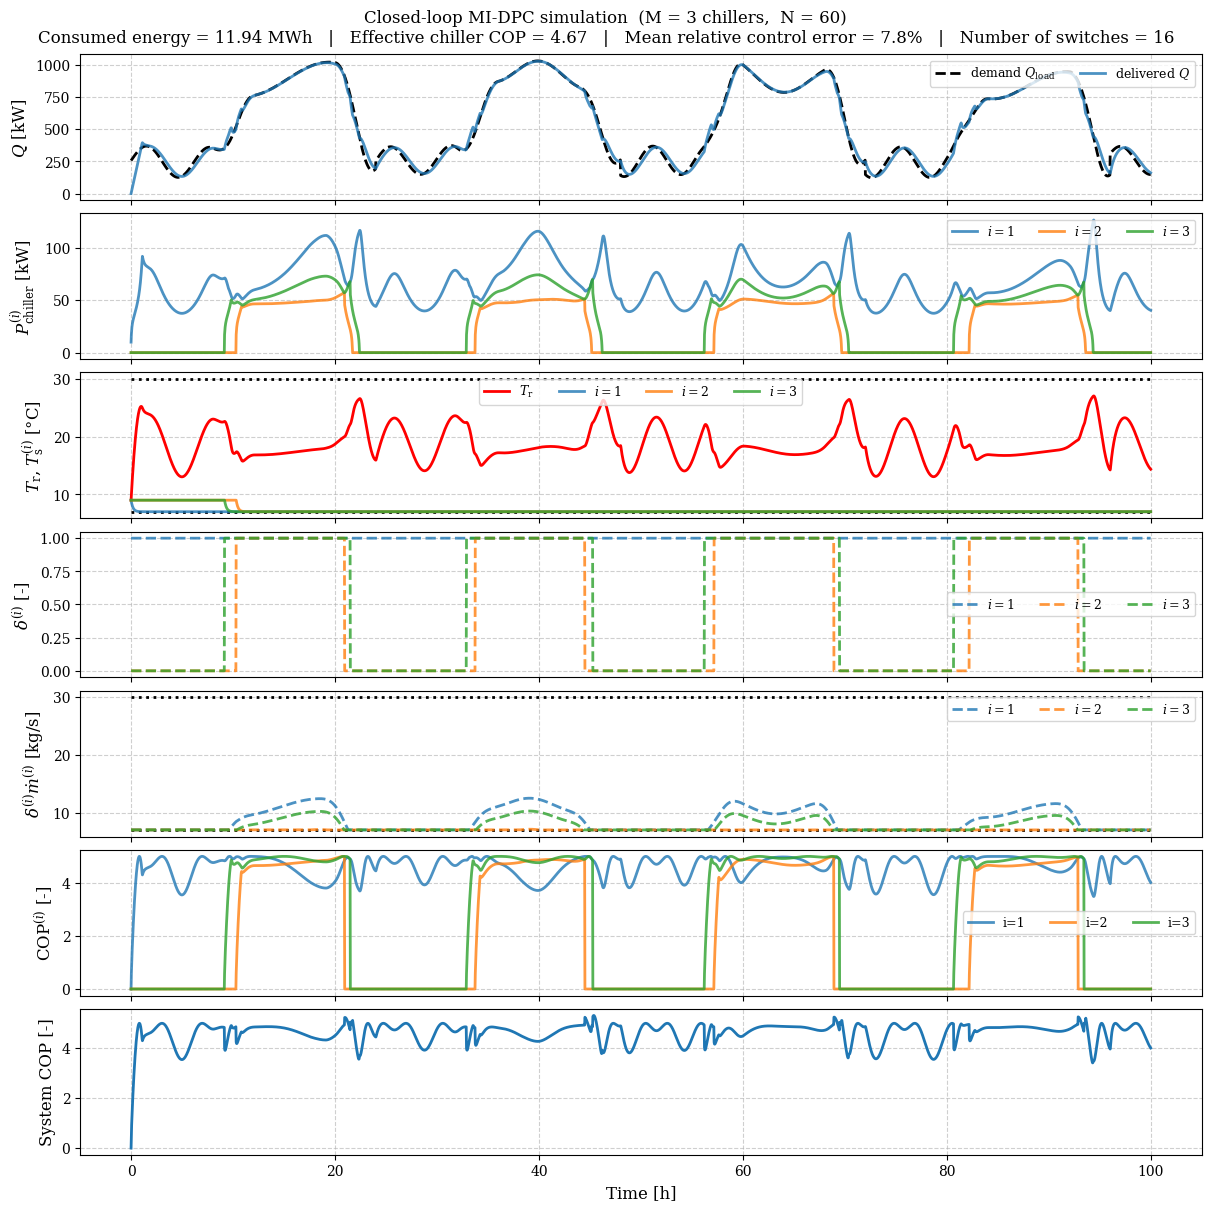

In [24]:

# ----------------------------------------------------------------------
# 1) Collect the closed-loop trajectories
# ----------------------------------------------------------------------
M, Ts = system.M, system.Ts
N_plot = s_length
t = np.arange(N_plot) * Ts / 3600.0                       # time axis in hours

integer = trajectories['integer'][0, :N_plot, :]          # [T, M]
relaxed = trajectories['relaxed_integer'][0, :N_plot, :]  # [T, M-1]
flow = trajectories['flow'][0, :N_plot, :]             # [T, M]
T_evap = trajectories['T_evap'][0, :N_plot, :]           # [T, M]
state = trajectories['T_supply_and_return'][0, :N_plot, :]
T_supply = state[:, :M]                                    # [T, M]
T_return = state[:, M:]                                    # [T, 1]
load = trajectories['load'][0, :N_plot, :]             # [T, 1]

# ----------------------------------------------------------------------
# 2) Recover the physical quantities (cooling and power)
# ----------------------------------------------------------------------
Q_chiller = trajectories['Q_delivered'][0, :N_plot, :]                              # [T, M]
Q_total = Q_chiller.sum(dim=-1, keepdim=True)
P_chiller = system.get_chiller_power_PLR_(
    cooling=Q_chiller, integer_status=integer)                                      # [T, M]
P_pump = system.get_pump_consumption(integer_status=integer, mass_flow=flow)     # [T, M]
P_total = (P_chiller + P_pump).sum(dim=-1, keepdim=True)

to_np = lambda x: x.detach().cpu().numpy()
integer, relaxed, flow, T_evap = map(to_np, (integer, relaxed, flow, T_evap))
T_supply, T_return, load = map(to_np, (T_supply, T_return, load))
Q_chiller, Q_total, P_total, P_chiller, P_pump = map(to_np, (Q_chiller, Q_total, P_total, P_chiller, P_pump))

# ----------------------------------------------------------------------
# 3) Performance metrics
# ----------------------------------------------------------------------
eps = 1e-6
EC = P_total.sum() * Ts / 3600.0 / 1000.0                 # energy consumption [MWh]
EC_COP = Q_total.sum() / (P_chiller.sum() + eps)              # effective chiller COP [-]
RCE = np.mean(np.abs(load - Q_total) / (load + eps)) * 100 # mean relative control error [%]
num_switch = int(np.abs(np.diff(integer, axis=0)).sum())          # number of on/off switches
print(f'Energy consumption : {EC:7.3f} MWh')
print(f'Effective COP      : {EC_COP:7.2f}')
print(f'Mean relative control error           : {RCE:7.2f} %')
print(f'Number of switches : {num_switch}')

# ----------------------------------------------------------------------
# 4) Closed-loop trajectory plot
# ----------------------------------------------------------------------
plt.rcParams.update({'font.family': 'serif', 'mathtext.fontset': 'dejavuserif', 'lines.linewidth': 2.})
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
fig, ax = plt.subplots(7, 1, figsize=(12, 12), sharex=True, layout='constrained')
fig.suptitle(
    f'Closed-loop MI-DPC simulation  (M = {M} chillers,  N = {nsteps})\n'
    f'Consumed energy = {EC:.2f} MWh   |   Effective chiller COP = {EC_COP:.2f}   |   ' f'Mean relative control error = {RCE:.1f}%   |   Number of switches = {num_switch}',
    fontsize=12)

# (a) cooling demand tracking
ax[0].plot(t, load[:, 0], 'k--',  label=r'demand $Q_\mathrm{load}$')
ax[0].plot(t, Q_total[:, 0], color=colors[0],   label=r'delivered $Q$', alpha=0.8)
ax[0].set_ylabel(r'$Q$ [kW]', fontsize=12); ax[0].legend(loc='upper right', ncol=2, fontsize=9)

# (b) electrical power consumption
for i in range(M):
    ax[1].plot(t, P_chiller[:, i], color=colors[i],  label=fr'$i={i+1}$', alpha=0.8)
ax[1].set_ylabel(r'$P_\mathrm{chiller}^{(i)}$ [kW]', fontsize=12); ax[1].legend(loc='upper right', ncol=3, fontsize=9)

# (c) System temperatures
ax[2].plot(t, T_return, 'r',  label=r"$T_\mathrm{r}$")
ax[2].hlines(system.T_return_min, 0, t[-1], 'k', linestyle=':'); ax[2].hlines(system.T_return_max, 0, t[-1], 'k', linestyle=':')
for i in range(M):
    ax[2].plot(t,T_supply[:,i], label = fr'$i={i+1}$', alpha=0.8)
ax[2].set_ylabel(r'$T_\mathrm{r}$, $T_\mathrm{s}^{(i)}$ [°C]', fontsize=12); ax[2].legend(loc='best', ncol=4, fontsize=9)

# (d) Chiller status -- ON/OFF
for i in range(M):
    ax[3].plot(t, integer[:,i], alpha=0.8, ls='--', label=fr'$i={i+1}$')
ax[3].set_ylabel(r'$\delta^{(i)}$ [-]', fontsize=12); ax[3].legend(loc='best', ncol=4, fontsize=9)

# (e) Coolant mass flow
ax[4].hlines(system.flow_min, 0, t[-1], 'k', linestyle=':'); ax[4].hlines(system.flow_max, 0, t[-1], 'k', linestyle=':')
for i in range(M):
    ax[4].plot(t, flow[:,i], alpha=0.8, ls='--', label=fr'$i={i+1}$')
ax[4].set_ylabel(r'$\delta^{(i)}$$\dot m^{(i)}$ [kg/s]', fontsize=12); ax[4].legend(loc='best', ncol=4, fontsize=9)

# (f) Coefficient of performance (COP) per chiller
COP_chiller = Q_chiller / (P_chiller + eps)               # [T, M]
COP_chiller = np.where(integer > 0.5, COP_chiller, 0.)  # off periods
for i in range(M):
    ax[5].plot(t, COP_chiller[:,i], label = f'i={i+1}', color=colors[i], alpha=0.8)
ax[5].set_ylabel(r'$\text{COP}^{(i)}$ [-]', fontsize=12); ax[5].legend(loc='best', ncol=4, fontsize=9)

# (g) System COP
ax[6].plot(t, Q_total / (P_total+1e-2))
ax[6].set_ylabel(r'System COP [-]', fontsize=12); ax[6].set_xlabel('Time [h]', fontsize=12)

for ax in fig.axes:
    ax.grid(True, linestyle='--', alpha=0.6)